# Electromagnetism Homework #2
### Due: Friday, February 6, 2026 at 5:00PM
Problems marked with [*] are potential sources for quiz questions.

## Problem 1: Do the following (1-4)
1.  Find the conduction electron number density, $n$, in a piece of copper, assuming each atom contributes one free electron. (Look up the necessary physical constants.)

-------------------------------------------------------------------------------------
2. Calculate the average electron velocity, ie the drift velocity, in a copper wire 1-mm in diameter, carrying a current of 1 A.

-------------------------------------------------------------------------------------
3. For copper, at room temperature the electrons form a degenerate Fermi gas with rms speed of $vrms ≈ 1.22 × 106 m/s$. This is the speed at which the free electrons are whizzing around randomly inside the copper. The drift velocity is superimposed on top of this random motion and is many, many, orders of magnitude smaller.

-------------------------------------------------------------------------------------
4. Write a simple computer code to convince yourself that a small but steady drift velocity will emerge when averaging a large number of random thermal velocities with the drift velocity superimposed.

Hint: Do not use the real thermal velocity or drift velocity. Pick something like a drift “speed” of 0.01 and a thermal “speed” chosen randomly from the range (−1,1).
If using Python, take a look at numpy’s random library: https://numpy.org/doc/stable/reference/random/index.html.

Warning: The smaller you make the drift speed, the more averages you need to take before the drift becomes apparent. This is expected behavior and reflects the physics of the problem. Very large numbers of averages may take a long time to run or cause memory issues

## Problem 1 Solution: Conceptual (1-3)

### 1. 
For the conduction electron number density you must know the molar mass of the piece of copper, the number of free electrons per atom, and the mass per unit volume of the copper. The number of conduction atoms is assumed to be 1. After looking up the mass per unit volume of copper, I found it to be 8960 kg per cubic meter or 8.96 grams per cubic centimeter. We must also use avogadros number in this equation which will be down below. The final piece is knowing the molar mass of the piece of copper. Putting all of this together we get the equation: $$n = \frac{(\rho * Z) * (6.022 * 10^{23} mol^{-1})}{M}$$ 
Plugging all these in results in $8.49 * 10^{28} electrons/m^3$

-------------------------------------------------------------------------------------
### 2. 
So I thought this last equation was wrong and I was about to use the equation from the notes, but I found out it is correct. What I didn't realize was that the n in the equation from day 1 notes is what im looking for in question 1. 

Anyways now that we have our answer for question 1 we can find our drift velocity from the equation: $$i = nAv_{drift}$$
Rearranging: $$v_{drift} = \frac{i}{nA}$$
Just so its in here, i is the current, n is the conduction electron number density, and A is the cross section area of the wire. Lets go ahead and write down the area $A = \pi r^{2} = \pi (0.0005m)^{2} = 7.85 * 10^{-7} m^{2}$. 

Now we can solve our equation for the drift velocity: $$v_{drift} = \frac{1}{(8.49 * 10^{28})(7.85 * 10^{-7})}$$
This gives us a drift velocity of: $1.5 * 10^{-23}$ m/s

This does not seem right. And I was right about that. What we are missing is the basic charge of one electron which is $1.602 * 10^{-19}$ C. Throwing that into the denominator gives us: $$v_{drift} = \frac{1}{(8.49 * 10^{28})(1.602 * 10^{-19})(7.85 * 10^{-7})}$$
This then comes out to: $v_{drift} = 9.4 * 10^{-5}$ m/s. This looks right as its very slow but not as slow as our other answer. Reading the notes I know that the drift velocity is supposed to be slow. Usually less than a millimeter a second. 

-------------------------------------------------------------------------------------
### 3. 
The answer to problem 2 fits this statement. 

### Problem 1 Solution: Coding (4)

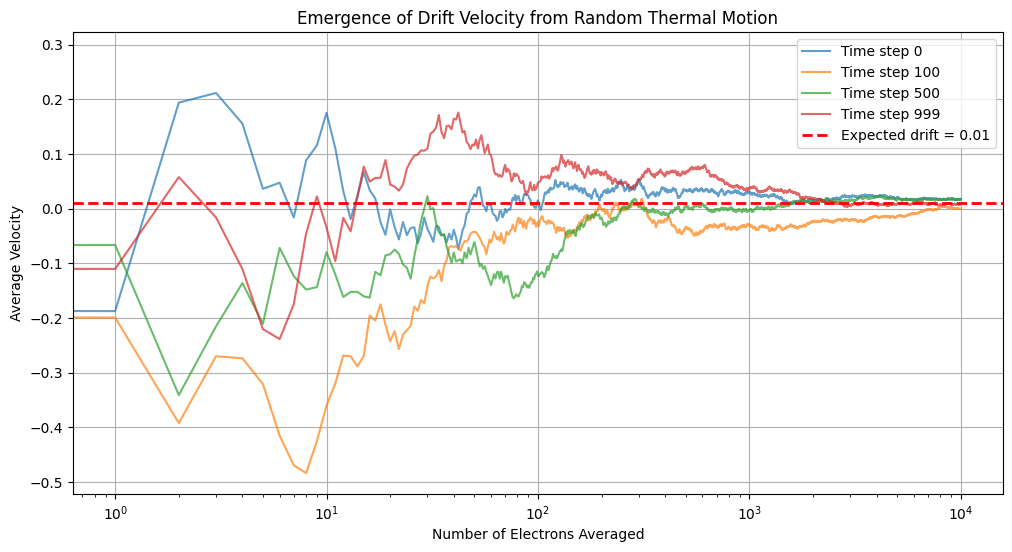

Expected drift velocity: 0.01
Measured average velocity: 0.009953
Percent error: 0.47%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
drift_speed = 0.01  # Small drift velocity
n_electrons = 10000  # Number of electrons to simulate
n_samples = 1000     # Number of time steps

# Generate random thermal velocities in range (-1, 1)
thermal_velocities = np.random.uniform(-1, 1, (n_samples, n_electrons))

# Add drift velocity to thermal motion
total_velocities = thermal_velocities + drift_speed

# Calculate cumulative average velocity over increasing numbers of electrons
cumulative_avg = np.cumsum(total_velocities, axis=1) / np.arange(1, n_electrons + 1)

# Plot results for several time snapshots
plt.figure(figsize=(12, 6))

# Plot cumulative average for a few time steps
for i in [0, 100, 500, 999]:
    plt.plot(cumulative_avg[i, :], label=f'Time step {i}', alpha=0.7)

plt.axhline(y=drift_speed, color='r', linestyle='--', linewidth=2, label=f'Expected drift = {drift_speed}')
plt.xlabel('Number of Electrons Averaged')
plt.ylabel('Average Velocity')
plt.title('Emergence of Drift Velocity from Random Thermal Motion')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.show()

# Print final average
final_avg = np.mean(total_velocities)
print(f"Expected drift velocity: {drift_speed}")
print(f"Measured average velocity: {final_avg:.6f}")
print(f"Percent error: {abs(final_avg - drift_speed)/drift_speed * 100:.2f}%")

## Problem 2: 
A battery of emf $\epsilon$ and internal resistance r is hooked up to a variable "load" resistance, R, as illustrated below. 

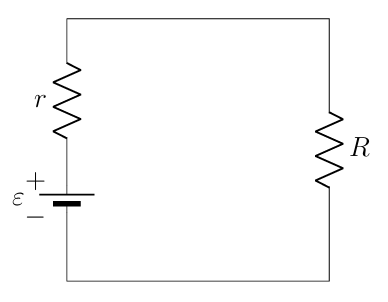

-------------------------------------------------------------------------------------
1. Show that an expression for the power $P_{L}(R)$ delivered to the load resistor in terms of the battery emf $(\epsilon)$, the battery internal resistance (r), and the load resistance (R) is: $$P_{L}(R) = \frac{\epsilon^{2}R}{(R+r)^{2}}$$

-------------------------------------------------------------------------------------
2. The efficiency, η, is the ratio of the energy (or power) doing what we want divided by the total energy (or power) it takes to do it. Assume the battery is 100% efficient in converting chemical energy into electrical energy. Show that the efficiency of this circuit is given by: $$\eta(R) = \frac{R}{R+r}$$

-------------------------------------------------------------------------------------
3.  Find the load resistance that maximizes the power delivered to the load. (You can’t change ε and r, of course.) Determine the efficiency at this max power load resistance. What do you think about that efficiency? (good, bad, meh?) What does that value of load resistance imply about the energy dissipated in the battery?

-------------------------------------------------------------------------------------
4.  A typical new 12-V car battery has an emf of 12-V and an internal resistance of 5-mΩ (yes, milli-ohms). Make plots of PL(R) and η(R) for R in the range 0.1mΩ < R < 1Ω. Clearly highlight the value of r in the plot(s). Hint: use logarithmic scaling on the x-axis. You can also put both plots on one graph - just make them distinctive.

-------------------------------------------------------------------------------------
5. A typical starter motor draws several hundred amps from the battery and has an effective winding resistance on the order of 10–30 mΩ, which is larger than the battery’s internal resistance (∼ 10 times larger). Using your plots and calculations, explain why the starter motor winding resistance is not designed to equal the battery’s internal resistance, even though that would maximize power transfer.

### Problem 2 Solution: 

#### 1. 
To start this off I want to know the basic equation for power in terms of Ohm's law. Power is the rate at which work is done over time. After looking through some notes and the book I found that: $$P = V \cdot I = I^{2}R = \frac{V^{2}}{R}$$

I also found out that IR and I^2 R is called the Joule heating law. Looking at equation 7.10 in Griffiths 4th edition we see that $V = \epsilon$. We can then replace the V in the above equations: $$P = \epsilon \cdot I = I^{2}R = \frac{\epsilon^{2}}{R}$$

We must also remember that the emf is equal to the negative change in flux: $$\epsilon = -\frac{d\Phi}{dt}$$

I'm pretty much just writing down the pieces and hoping I can connect them. Anyways like a baby bird jumping out of the nest for the first (really the second) time here I go. If we know that there are two resistances in series in the circuit, then we can just add them: $$P = \frac{\epsilon^{2}}{(R + r)}$$

I think were getting there, but obviously i'm missing something. Just to add to the collection of random equations related to the emf, lets write down this one: $$\epsilon = \oint f_{s} \cdot \,dl$$

While looking through youtube I got reminded that Ohms law exists even though its pretty much already in these notes. Replacing $\epsilon$ with IR we get: $$P = \frac{(IR)^{2}}{(R + r)}$$

Okay I think I'm dumb or something. I realized earlier that I had ohms law to use but I dont think I used it right. After doing this on paper and ignoring the power for this part I have: $$I = \frac{\epsilon}{R_{tot}} \space = \space \frac{\epsilon}{R+r}$$

Now we can worry about the power with the equation $P = I^{2}R$. Now plugging in: $$P = (\frac{\epsilon}{R+r})^{2}R$$

I actually hate myself sometimes for not being diligent enough to see this at the start. Anyways now we have everything we need and can simplify this down. First: $$P = \frac{\epsilon^{2}}{(R+r)^{2}}R$$

Now literally just move the R over and we get the right answer: $$P_{L}(R) = \frac{\epsilon^{2}R}{(R+r)^{2}}$$

-------------------------------------------------------------------------------------
#### 2. 
Okay okay this one shouldn't be hard to figure out. Then again we can see the trouble I had on the last one. Anyways lets begin with the power for the last problem: $$P_{L}(R) = \frac{\epsilon^{2}R}{(R+r)^{2}}$$

We want this power to go into the load resistance so this means this is the power doing what we want. So whats the expression for the power it takes to do it? What I really want to do is just subtract, divide, or whatever this equation for power $P = \frac{\epsilon^{2}}{(R + r)}$ by the one above. Now just looking at them it looks like it'll get the right answer, but let me try that on paper. 

I was just about to write and then I realized that the power that I want to do something with would be the total power it takes to do this. Now im actually writing. 

Okay it turns out I was right. I took the original equation for just power, put it in terms of $\epsilon$, and then plugged it into the ratio. Here's my writing on paper: 
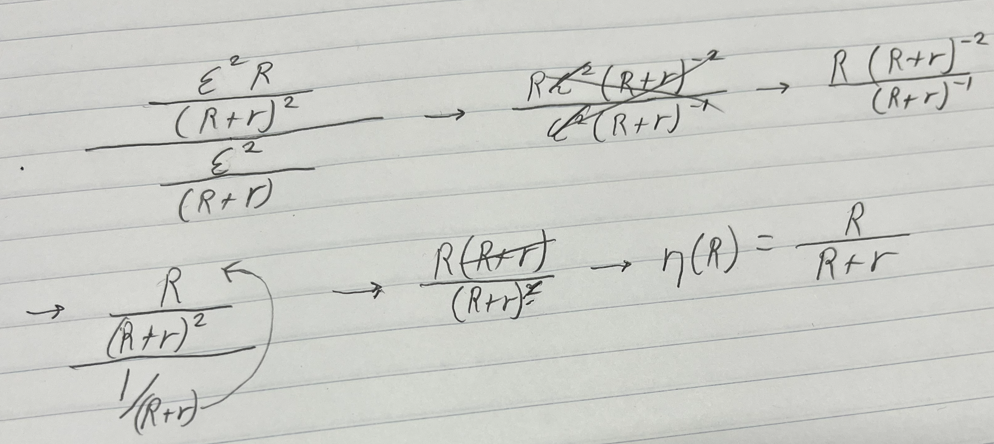

-------------------------------------------------------------------------------------
#### 3. 
To understand how to solve this problem I need to understand how the last two problems resulting equations work. Like if we dont change $\epsilon$ or r, then what happens when we change R? We must first understand the first resulting equation for power delivered to the load resistor. Lets start with that then get to the rest of the questions. 

Starting with problem one's result: $$P_{L}(R) = \frac{\epsilon^{2}R}{(R+r)^{2}}$$

After some research I relearned that to find the maximum of a function you have to follow some calculus steps. Again I am trying not to use AI when I can, but Ill let you know when I do use it. Anyways you take the first derivative of this function, set the result equal to zero, and then find the critical points. After this you take the second derivative and find where the function is less than zero to find the local max. This is due to the fucntion there being concave down indicating a local max. Now to save myself time I used AI to compute these derivatives and give me some hints. It turns out that when R = r, the load resistor is maximizing the power delivered. This is apparently called Jacobi's Law or the Maximum Power Transfer Theorem. It means that to get the most power out of the battery, the load resistance must match the battery's internal resistance. This concept will be answered in part 5 of this problem. 

Anyways lets move on to the math behind the above paragraph. Gemini AI used the quotient rule $(\frac{u}{v})^{'} = \frac{u^{'}v - uv^{'}}{v^{2}}$ to compute the first derivative. The resulting equation after simplification is: $$P_{L}^{'}(R) = \frac{\epsilon^{2}(r - R)}{(R+r)^{3}}$$

Setting the above derivative equal to 0 results in the critical point R = r. This is where the theorem mentioned above is found. Something that it also said is that the denominator can be set to zero in a real circuit. This is interesting because AI is "thinking" of that while doing this. I should say considering, but anyways the second derivative check is as follows: $$P_{L}^{''}(R) = -\frac{\epsilon^{2}}{8r^{3}}$$

Since the numerator and denominator are always positive, this confirms that this is a local max. Now we can plug this result into our original equation. I'll spare you the process which isn't too hard to do, but the result of this is: $$P_{max} = \frac{\epsilon^{2}}{4r}$$

To find the efficiency at this max power load resistance we just need to plug it into the equation from problem 2. I'm meaning follow the same process. I'll go ahead and type this out, but we end up with the same result if we set R = r in the second part. Starting with: $$\frac{\frac{\epsilon^{2}}{4r}}{\frac{\epsilon^{2}}{2r}}$$

After this move the denominator to the numerator: $$\frac{\epsilon^{2}(4r)^{-1}}{\epsilon^{2}(2r)^{-1}}$$

Now cancel the epsilons and move 2r to the numerator and then simplify leaving us with: $$\eta (R) = \frac{1}{2} = 50%$$

This seems like a pretty bad efficiency. Compared to cars with an efficiency of like 33% (If I remember correctly) its not too bad. I'm sure theres things we use often with a worse efficiency. Anyways of course I wonder if theres a way to maximize this like we just did with the power. We will get to that soon. 

What that value of load resistance implies about the energy dissipated in the battery is that you are dissipating the same amout of heat energy in the battery as you are getting out of it. This would probably make it blow up. 

-------------------------------------------------------------------------------------
#### 4. 
See coding cell below this markdown. 

-------------------------------------------------------------------------------------
#### 5. 
So the answer of this question is directly tied to what we discussed in part 3 of this problem. To put things in simple terms, if the winding resistance was the same as the batteries internal resistance then the battery would probalby explode or over heat causing it to not work. To maximize the battery's usage the winding needs to have that resistance that is 10 times larger than the battery's internal resistance. This will result in lower power yes, but the battery is still able to provide the starter motor with enough power to start the car. This makes it to where the power dissipated in the battery is as low as it can get. This is the simple answer of this the way I understand it. 


<>:41: SyntaxWarning: invalid escape sequence '\e'
<>:42: SyntaxWarning: invalid escape sequence '\e'
<>:41: SyntaxWarning: invalid escape sequence '\e'
<>:42: SyntaxWarning: invalid escape sequence '\e'
C:\Users\hogwi\AppData\Local\Temp\ipykernel_13256\1350829428.py:41: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel('Efficiency $\eta(R)$', color=color, fontsize=12)
C:\Users\hogwi\AppData\Local\Temp\ipykernel_13256\1350829428.py:42: SyntaxWarning: invalid escape sequence '\e'
  ax2.plot(R, eta, color=color, linewidth=2, linestyle='-.', label='$\eta(R)$')


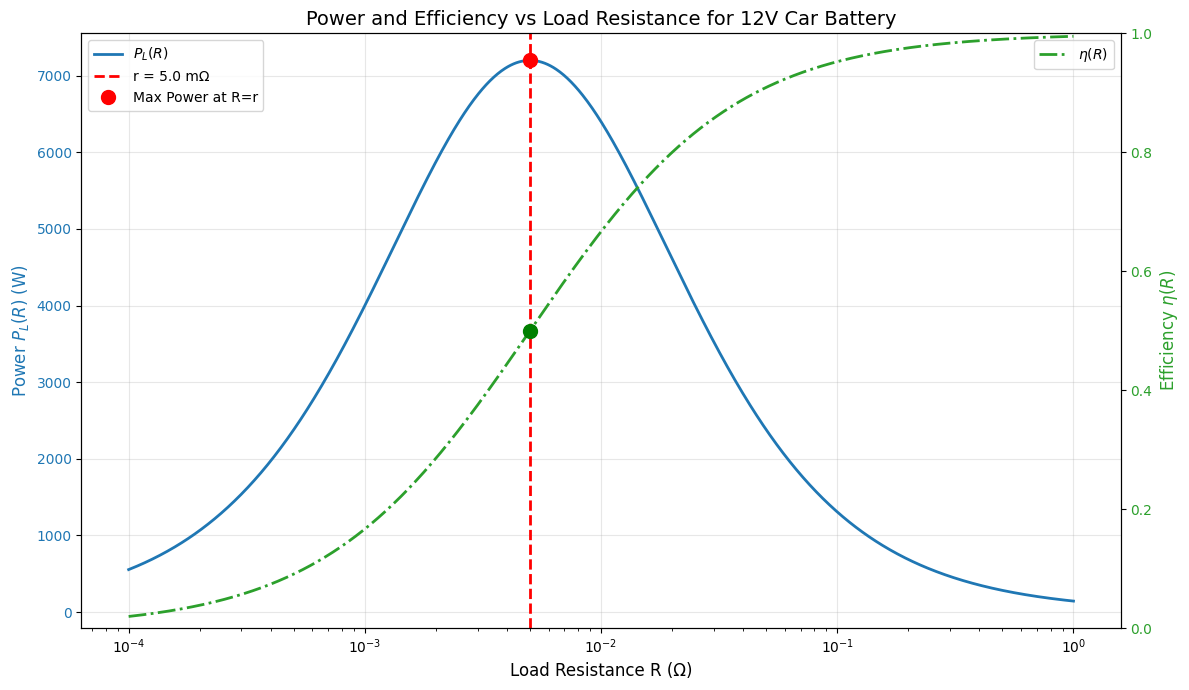

Battery emf: 12 V
Internal resistance r: 5.0 mΩ
Maximum power at R = r: 7200.00 W
Efficiency at max power: 50%


In [2]:
#### Problem 2 Part 4 Plot 
# This code was done by copilot in VSCode 
# it is based on the results from the conceptual questions

import numpy as np
import matplotlib.pyplot as plt

# Battery parameters
epsilon = 12  # V
r = 5e-3  # 5 mΩ in Ohms

# Load resistance range: 0.1 mΩ to 1 Ω
R = np.logspace(np.log10(0.1e-3), np.log10(1), 1000)  # logarithmic spacing

# Power delivered to load
P_L = (epsilon**2 * R) / (R + r)**2

# Efficiency
eta = R / (R + r)

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plot power on left y-axis
color = 'tab:blue'
ax1.set_xlabel('Load Resistance R (Ω)', fontsize=12)
ax1.set_ylabel('Power $P_L(R)$ (W)', color=color, fontsize=12)
ax1.plot(R, P_L, color=color, linewidth=2, label='$P_L(R)$')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

# Highlight r = 5 mΩ on power curve
P_at_r = (epsilon**2 * r) / (2*r)**2  # Power when R = r
ax1.axvline(x=r, color='red', linestyle='--', linewidth=2, label=f'r = {r*1e3:.1f} mΩ')
ax1.plot(r, P_at_r, 'ro', markersize=10, label=f'Max Power at R=r')

# Create second y-axis for efficiency
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Efficiency $\eta(R)$', color=color, fontsize=12)
ax2.plot(R, eta, color=color, linewidth=2, linestyle='-.', label='$\eta(R)$')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim([0, 1])

# Highlight efficiency at r
eta_at_r = 0.5
ax2.plot(r, eta_at_r, 'go', markersize=10)

# Add title and legends
plt.title('Power and Efficiency vs Load Resistance for 12V Car Battery', fontsize=14)
ax1.legend(loc='upper left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Print key values
print(f"Battery emf: {epsilon} V")
print(f"Internal resistance r: {r*1e3:.1f} mΩ")
print(f"Maximum power at R = r: {P_at_r:.2f} W")
print(f"Efficiency at max power: {eta_at_r*100:.0f}%")


### Problem 3 [*] 
A metal bar of mass m slides frictionlessly on two parallel conducting rails a distance ℓ apart as shown below. A resistor R is connected across the rails and a uniform magnetic field B, pointing into the page, fills the same region.

-------------------------------------------------------------------------------------
1. If the bar moves to the right at speed v, what is the current in the resistor? In what direction does it flow?

-------------------------------------------------------------------------------------
2. What is the magnetic force on the bar? What direction?

-------------------------------------------------------------------------------------
3. If the bar starts out with speed v0 at time t = 0, and is left to slide, what is its speed at a later time t?

-------------------------------------------------------------------------------------
4. The initial kinetic energy of the bar was, of course, $\frac{1}{2}mv_{0}^{2}$. Check that the energy delivered to the resistor is exactly $\frac{1}{2}mv_{0}^{2}$.

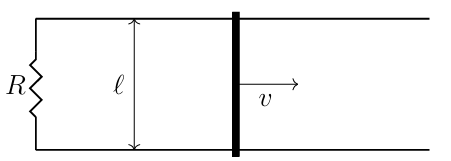

### Problem 3 Solution: 

### 1. 
I am going to treat this problem similarly to how I did problem 2. Things seemed to work out when I gathered equations and concepts and then tried to mash them together. To start off, I remember from class that the current or something cancels out because of part of the circuit being parallel with itself. This means the only thing contributing is the part with the resistor. 

After reading through the book, specifically on page 307 in Griffiths 4th edition, I found that we are going to be dealing with motional emf. It will follow the flux rule for motional emf which is: $$\epsilon = -\frac{d\Phi}{dt}$$

I found a youtube video of someone who solved this problem. 
[Link text][Griffiths-Problem-7.7]: https://www.youtube.com/watch?v=riA8_Ln_ktY

I swear at this point I have not watched the video because I don't want to simply copy down their work. My plan is to use it like AI where it is a verification of my work or a hint. 

From the chapter 7 day 2 notes on black board I found that the part of the circuit with the resistor experiences a magnetic force of qvB or $f_{mag} = vB$. From this the emf is $\epsilon = vBh$. This is great, but I think this problem will work differently. Instead of pulling on the circuit with velocity v, the bar kind of replaces that. I'm wondering if I can just use the equations the same. 

Since the bar is moving to the right at speed v inside of a magnetic field pointed into the page, we can assume that this will cause a change in the magnetic flux. This is happening in the bar. That change in magnetic flux will induce a current in the bar which will then cause ANOTHER magnetic field to be produced that is pointing out of the page. This will tie into where the current in the resistor comes from. This understanding comes from an audio recording that I took in class on February 6 explaining how this works. 

Since the magnetic field is changing, that energy will go through the circuit into the resistor. This makes me initially think that the direction of the current in the resistor will be in the same direction as the bar. I could be wrong though. For now though lets try to solve for the current. 

Since the moving bar causes a chagning magnetic flux that results in an induced current in the circuit, we can try start with just that. The magnitude of the magnetic field in the area we are looking at doesn't change. The separation of the circuit is constant as well. The only thing changing is how far away the bar is. This comes from page 307 in Griffiths 4th edition where it says that: $$\Phi = Bhx$$

As a result of the B field and h being constant we are taking the derivative of x over time. The equation follows: $$\frac{d\Phi}{dt} = Bh\frac{dx}{dt} = -Bhv$$

We already know that -Bhv is the emf. What we also know from problem 2 is that the emf is also equal to IR. Now we have the current into the equation and we can solve for it: $$-Bhv = IR$$

Solving for I: $$I = -\frac{Bhv}{R}$$

Since this result is negative and current cant really be negative, I think this is saying something about the magnetic field induced by the current that is flowing through the resistor. The direction of the current is going to oppose the magnetic field that is into the page. This will cause the magnetic field induced by it to oppose the existing one. This means that the current is flowing counter-clockwise and the resulting magnetic field points out of the page. After reviewing the answer to the first part of the video above, I got the same result. The only difference is that my answer was negative and theirs was positive. 

-------------------------------------------------------------------------------------
### 2. 
For the magnetic force on the bar I think I wrote down enough to have a good general understanding of whats going on in this problem. We've got a lot of opposing things going on. My initial guess is that the force on the bar is opposing its direction of motion. Not enough to instantly stop it or anything, but enough to keep current flowing in the resistor. The velocity will be slowing down as will the amount of current in the resistor. 

Let me write this down so it doesn't get lost: $$\epsilon = \oint f_{mag} \cdot \, dl = vBh$$

Here we have an equation of force. Since the bar is slowing down by my guess then there has to be an acceleration acting on it in the negative x direction. Reading through the book I realized this is related to how the jumping ring example from class works. The flux from the coil induced a current in the ring whose magnetic flux opposed the flux from the coil causing it to jump. 

So I know that the force on the bar will be caused by the induced current opposing the B field. I looked up in the search bar, "force from induced current". I am a picture kind of person and this is what I found: 

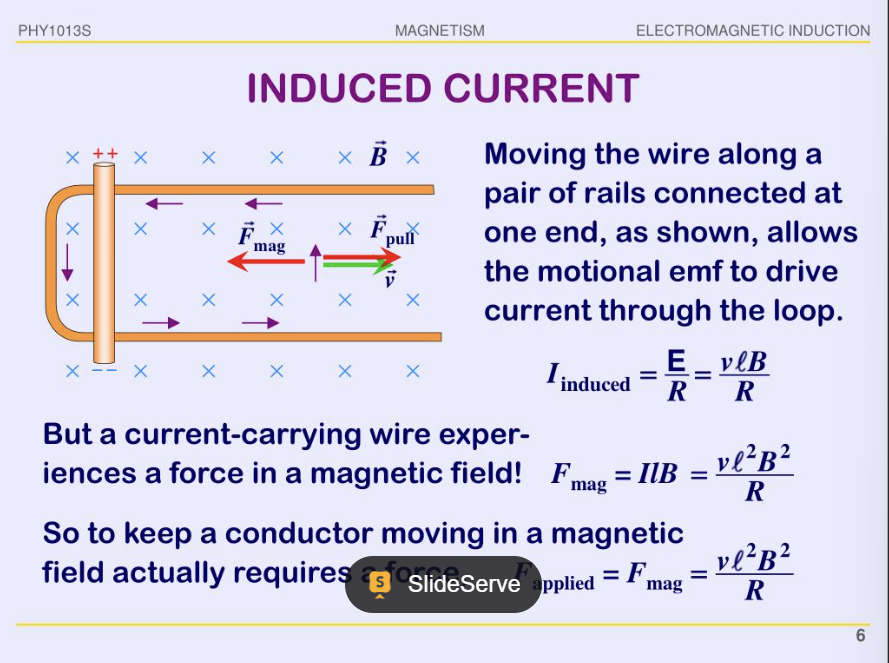

I don't know the electric field, but I could probalby find it. That probalby not the point or the best method since I already know the induced current. We can use the equation for the force from this image though. I wanted proof that this was correct. If you go to page 217 in Griffiths 4th then you find equation 5.16 which is: $$F_{mag} = \int I(dl \times B)$$

This confirms that were on the right path and I think we can simply plug in our answer for part 1 into this to find the force. Lets do this assuming the length of the bar is the same as l in our problem: $$F_{mag} = lB(-\frac{Bhv}{R})$$

Since $l = h$ we can just combine the terms which gives us our answer: $$F = -\frac{vl^{2}B^{2}}{R}$$

I guess at this point im keeping the negative in there because this force opposes the bars motion. 

-------------------------------------------------------------------------------------
### 3. 
I wonder if I can just use kinematics to solve this part. The bar has a mass (m) and velocity that is slowing down at a constant rate (I think). We need to find t and we have pretty much everything we need. We can solve for the acceleration from Newton's second giving us $a = \frac{F}{m}$. I guess we just need to pick one at this point. We could simplify this by finding what time the bar would stop moving or v = 0. Lets go with $$v = v_{0} + at$$

Okay after doing this on paper I was like "wait something isn't right". First off the fraction looked like alot and I had a $v_{0}$ and normal v. Then I got confused on what I was even solving for. Anyways after reviewing and getting a hint from the video I am going to try thier initial set up. It was done with a differential equation that looks like: $$m\frac{dV}{dt} = -\frac{vl^{2}B^{2}}{R}$$

Ill attach a picture of the process of this solution. I ended up finding: $$v = v_{0}(e^{-\frac{l^{2}B^{2}}{mR}t})$$

Heres my paper: 

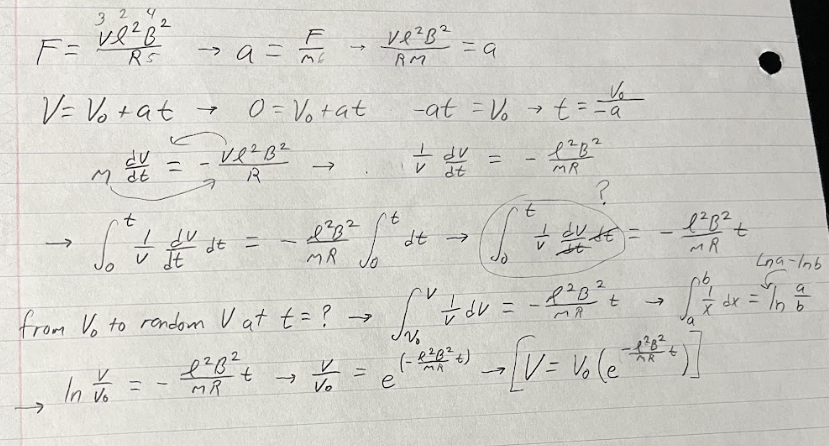

Just plug in what ever t you want and boom. As t goes to infinity the whole term inside the parenthesis goes to 0. What I was thinking earlier was correct. I said, "the velocity is slowing down at a constant rate (i think)". The I think part was from me thinking that as this bar slows down it will have less and less of an effect on the current. This will cause the force due to the current to decrease in an exponential manner. 

-------------------------------------------------------------------------------------
### 4. 
Okay I should be good at this now. I'm pretty sure we can think of the power delivered to the resistor as the energy delivered. Thats not this problem though so im not totally sure. Again I looked at the video for a hint and saw the first part of the solution to this part. I found out that I was right in thinking to use the power equation from earlier. This was: $$P = I^{2}R$$

Since we know the equation for I then we can find the power delivered over the time that the bar is moving. The equation that is set up is: $$\int_{0}^{\infty} I^{2}R \,dt$$

So the current from earlier is: $$I = -\frac{Bhv}{R}$$

We need to subsitute in our result from part three. ALso remember that h = l. This gives us this funky looking integral: $$R\int_{0}^{\infty} (\frac{lB}{R}v_{0}(e^{-\frac{l^{2}B^{2}}{mR}t}))^{2} \, dt$$

After integration, evaluation, and simplification we get: $$\frac{1}{2}mv_{0}^{2}$$

This is exactly what we were looking for and all the constants cancel out really nicely. 

Here's my work on paper: 

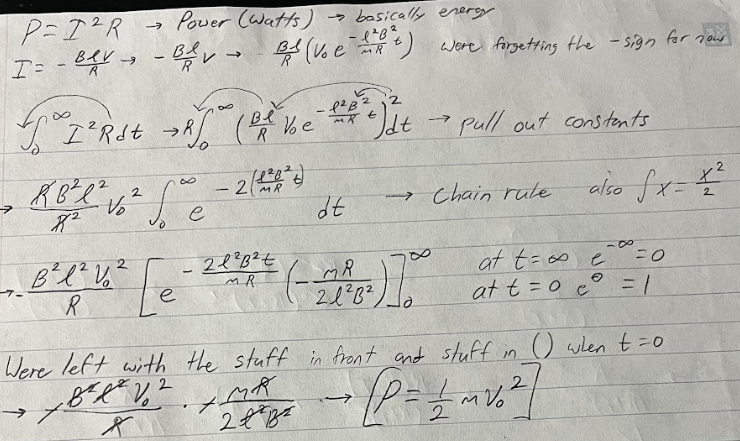


### Problem 4: 
An ideal inductor, illustrated below, used in circuit theory is often physically realized as a solenoid. In this problem, we will first derive the inductance of a solenoid from Maxwell’s equations and then apply the result to the design of an AM radio tuning circuit.

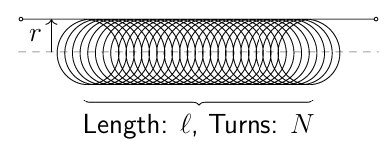


1. Consider a long solenoid of length ℓ, cross-sectional area A, and N tightly wound turns carrying a steady current I. Using Ampère’s Law, determine the magnetic field B inside the solenoid. Clearly state any assumptions used.

-------------------------------------------------------------------------------------
2. Calculate the magnetic flux through a single turn of the solenoid and hence determine the total flux linkage λ. Using the definition λ = LI, obtain an expression for the inductance L of the solenoid in terms of N, A, and ℓ.

-------------------------------------------------------------------------------------
3. The magnetic energy density is given by: $$u = \frac{B^{2}}{2\mu_{0}}$$
Compute the total magnetic energy stored in the solenoid and use it to rederive the inductance found in part (b). Comment briefly on the agreement between the two methods.

-------------------------------------------------------------------------------------
4. A simple AM radio receiver uses an LC circuit to select stations in the AM broadcast band, which spans frequencies from: $$f_{min} = 530kHz \space\space to \space\space f_{max} = 1700kHz$$
A typical AM variabe capacitor has a tuning range from: $$C_{max} = 365pF \space\space to \space\space C_{min} = 35pF$$

4 (i) ----> Assuming the circuit resonates at fmin when C = Cmax, determine the inductance L required for tuning. Recall the resonace frequency for a LC circuit is ω = 2πf = 1/√LC.

4 (ii) -----> Using this inductance, calculate the resonance frequency when C = Cmin. Is the full AM band covered?

-------------------------------------------------------------------------------------
5. The inductor is constructed by winding wire around a cylindrical ferrite rod with diameter $$D = 1.0cm$$
and winding length $$l = 10cm$$
Model the inductor as a solenoid with inductance $$L = \mu_{0}\mu_{eff}\frac{N^{2}A}{l},$$
where $\mu_{eff}$ is the effective relative permeability of the core.

5 (i): Calculate the number of turns required to achieve the inductance found in part (4), assuming $\mu_{eff} = 20$.

5 (ii): Repeat the calculation for an air-core inductor ($\mu_{eff} = 1$). By what factor does the required number of turns change?

-------------------------------------------------------------------------------------
6. Typical AM ferrite-rod inductors use on the order of 102 turns of wire. Is your result consistent with this expectation?

### Problem 4 Solution: 

### 1. 
In this problem we'll start with Ampere's Law with Maxwell's additions from page 334 in Griffiths 4th edition: $$\nabla \times B = \mu_{0}J + \mu_{0}\epsilon_{0}\frac{\partial E}{\partial t}$$

This again implies that a changing electric field induces a magnetic field. Looking at the image for this problem I thought it was a circular coil, but i'm now guessing its just coils around a bar or something. Also I think its a good idea to just use Ampere's Law before Maxwell to keep things more simple. This is Ampere's Law with the enclosed current. $I_{enc} = \int J \cdot \,da$. : $$\oint B \cdot \, dl = \mu_{0} I_{enc}$$

This is a line integral so we need to integrate along the path. I know that the magnetic field will be parallel to the path of the solenoid. Also im assuming the field outside is 0. With this the integral is just the field times the length $\oint B \cdot \, dl = BL$. Now our equation looks like: $$BL = \mu_{0} I_{enc}$$

We now need to find what $I_{enc}$ is in terms of the length, turns, and current. The number of turns per unit length is N/l. The enclosed area is this turns per unit length times the length L. J is the charge density which is basically the current over an area. Anyways we get this for $I_{enc}$: $$I_{enc} = (n*L)*I = \frac{NLI}{l}$$

Now we can plug in and solve for B: $$BL = \mu_{0}(\frac{NLI}{l})$$

And were left with: $$B = \mu_{0}(\frac{NI}{l}) \space = \space \mu_{0}nI$$

-------------------------------------------------------------------------------------
### 2. 
So for this one well start with flux in terms of the magnetic field: $$\Phi = \int B \cdot \, da$$

Now of course the area we would be integrating around is a circle. We don't need to worry about that yet and can keep the area as just A. This will give us a flux of: $$\Phi = A(\frac{\mu NI}{l})$$

After asking AI what flux linkage was exactly, it told me that it is the total flux that passes through every single loop of the wire. If you have N turns of wire, and the flux passes through all of them then the linkage is: $$\lambda = N \cdot \Phi$$

Or with what we have now: $$\lambda = N(\frac{\mu NIA}{l})$$

Simplified: $$\lambda = \frac{\mu N^{2} IA}{l}$$

Now all we have to do is use the equation given in the problem statement and then divide by I to get the inductance L: $$L = \frac{\mu N^{2} A}{l}$$

-------------------------------------------------------------------------------------
### 3. 
When writing everything down I realized I forgot to add the 0 to $\mu_{0}$. Well start with pluggin in our stuff for B then go from there: $$u = \frac{\mu_{0}N^{2}I^{2}}{2l^{2}}$$

I got really lost here and was unsure of where the connection was so I asked Gemini again. What it told me is that this problem is the bridge between field theory and circuit theory. Right now we have found our "field energy" and it gave me the circuit energy formula as: $$\frac{1}{2}LI^{2}$$

After multiplying the energy density by the area we get: $$U = \frac{\mu_{0}N^{2}I^{2}}{2l}$$

Funny this is the same thing as kinetic energy which makes good sense. Anyways we can use this. Set them equal to each other and solve for the inductance L and we get the same result as part 2. Here's some proof: $$\frac{1}{2}LI^{2} = \frac{\mu_{0}N^{2}I^{2}}{2l}$$

This leads us to the answer: $$L = \frac{\mu_{0} N^{2} A}{l}$$

What it tells us is that inductance is not dependent on current or voltage. It is a geometric property of the circuit dependant upon how the solenoid is wound. It proves that the inductance is the proportionality constant that links current to flux linkage and stored energy. 

-------------------------------------------------------------------------------------
### 4. 
Thank you for providing the resonance frequency for an LC circuit. Dr. Fred did a good job, but I forgot that. Anyways we need to solve that for L and then plug in our values. $$L = \frac{1}{(2\pi f)^{2}C}$$

Also I've been at this for awhile so im tired. Sorry if im not putting in as much excitement. Anyways at $f_{min}$ and $C_{max}$ we have: $$L = \frac{1}{(2\pi 530000)^{2} (365 * 10^{-12})}$$

After this we get: $$L = 2.47 * 10^{-4}H \space\space or \space\space 247 \mu H$$

This next part isn't that hard its just plugging in values so here we go: $$f = \frac{1}{2\pi \sqrt{(247 * 10^{-6})(35 * 10^{-12})}}$$

And we get: $$f = 1712 kHz$$

So yes we are able to cover the full AM band with a little room to spare. 

-------------------------------------------------------------------------------------
### 5. 
This problem is also not too hard. I just had to look up what $\mu_{0}$ equalled and embarrasingly what the area of a damn circle was. I got it confused with circumfrence again. Anyways we pull N out and get rid of the exponent and then plug in our values to find the number of turns. I did this on paper because its quicker than typing everything here. For $\mu_{eff} = 20$, I got: $$112 turns$$

And for $\mu_{eff} = 1$, I got: $$500 turns$$

The required number of turns changes by a factor of about 5. 

-------------------------------------------------------------------------------------
### 6. 
Thankfully my result is consistent with this expectation with $10^{2} = 100$ and my answer being 111.8 or 112 turns. 


### Problem 5 [*]: THE BIG ONE
In this problem we consider electrical power generation with a simple toy model illustrated below. A uniform magnetic field points in the $\hat{z}$ direction while a circular coil of wire rotates about its diameter with angular speed, $\omega$.
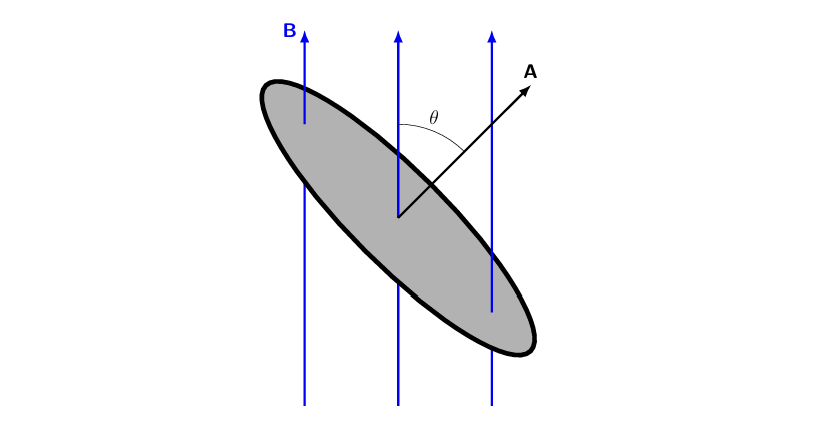
1. Compute the magnetic flux, $\Phi_{m}(t)$, for this system.

-------------------------------------------------------------------------------------
2. Compute the induced emf in the coil, ε(t).

-------------------------------------------------------------------------------------
3. Consider the coil having resistance in its windings, Rw, and inductance, L, and being in series with a load resistance, RL, as illustrated below. Use Kirchoff’s loop rule to write down an equation for the voltages around the loop for this circuit:
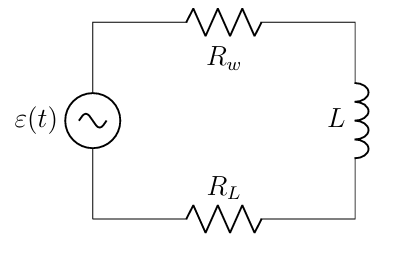

You should find: $$L\frac{dI}{dt} + R_{tot}I = \epsilon\sin{(\omega t)},$$

-------------------------------------------------------------------------------------
4. Integrate the ODE from the previous part to determine the steady state current in the coil, I(t). You should find: $$I(t) = \frac{\epsilon_{0}}{\sqrt{R_{tot}^{2} + (\omega L_{w})^{2}}}\sin(\omega t - \phi) = I_{0}\sin{(\omega t - \phi)},$$
where $\epsilon_{0} = NBA\omega$, $R_{tot} = R_{w} + R_{L}$, and $\phi = \tan^{-1}(\frac{\omega L}{R})$. Hint: We are assuming the coil has been rotating for a “long time” and are not intereted in the transient solution.

-------------------------------------------------------------------------------------
5. Do the following:

(i) What is the phase angle, φ, if ωL ≪ Rtot?

(ii) What is the phase angle if ωL ∼ Rtot

(iii) What is the phase angle if ωL ≫ Rtot?

These values span this simple generator's two regimes (resistance dominated and inductance dominated). 

-------------------------------------------------------------------------------------
6. Treat the flat, circular, coil as N turns of wire and compute it’s magnetic dipole moment, µ. Refer to Chapter 5, Equation 5.86.

-------------------------------------------------------------------------------------
7. Compute the torque on the coil in the B-field, $$\tau = \mu \times B$$
You should find the magnitude of the torque to be, $$\tau(t) = \frac{NAB I_{0}}{2} [\cos{\phi} - \cos{(2\omega t - \phi)}]$$

-------------------------------------------------------------------------------------
8. Compute an expression for the time-averaged torque, ⟨τ⟩, then evaluate it for our two regimes (resistance dominated and inductance dominated).

-------------------------------------------------------------------------------------
9. Recall from your physics class that the infinitesimal work done by a torque is, $dW = \tau d\theta$, such that the mechanical power is, $P_{mech}(t) = \tau(t)\omega$, where $\omega = \frac{d\theta}{dt}$ from the beginning of the problem. Compute the average mechanical power, $P_{mech}$. Then compute the electrical power delivered to $R_{tot}$, its average, and show that $P_{elec}$ equals $P_{mech}$. What does this mean?

-------------------------------------------------------------------------------------
10.  Assume the following numerical values: B = 0.5T, the coil has an area of $0.01 m^{2}$ and is composed of $N = 200$ turns of wire. The total resistance is $R_{tot} = 10$ Ohms and the frequency of rotation is 60Hz. Given the frequency and resistance compute effective inductance values for the ratios: $\frac{\omega L_{eff}}{R_{tot}} = [0.1, 1, 10]$. 

-------------------------------------------------------------------------------------
11. Make the following plots over several periods of oscillation:

11 (i): 
$\epsilon (t)$

11 (ii): 
I(t) for the three $\frac{\omega L_{eff}}{R_{tot}}$ cases. Put them all on one plot and make them distinctive. Comment on the plot (ie how is the phase angle showing up for each case).

11 (iii):
$\tau (t)$ for the three $\frac{\omega L_{eff}}{R_{tot}}$ cases.Put them all on one plot and make them distinctive. Comment on the plot (ie how is the phase angle showing up and what is $\tau$ for each case).

11 (iv):
$P_{mech}$ for the three $\frac{\omega L_{eff}}{R_{tot}}$ cases.Put them all on one plot and make them distinctive. Comment on the plot (ie how is the phase angle showing up and what is $P_{mech}$ for each case).

11 (v):
$P_{elec}$ for the three $\frac{\omega L_{eff}}{R_{tot}}$ cases.Put them all on one plot and make them distinctive. Comment on the plot (ie how is the phase angle showing up and what is $P_{elec}$ for each case). 


### Problem 5 Solution: (1 - 10)

### 1. 
So beginning this and reading through everything, I am assuming that I can use this flux equation: $$\Phi = \int B \cdot \, da$$

I need to do some more analysis to make sure I'm right. The angle of the coil should not matter in this case nor the rotation. These things would not change the flux through the magnetic field. Now as im writing this im considering that since it is rotating then does that cause a change in the magnetic flux which would then induce a current in the coil that opposes the uniform magnetic field. Lets try to think through this. 

If it were stationary, then there would be no change going on meaning no induced current or flux. That answers that. It is hard to look at this and move it in my head to a form that describes the motion of the electrons, but I get that theyre going round and round. 

I think this is more simple than I think so lets not over complicate this too much. The only thing left to consider is the angle $\theta$. If we look at this head on without seeing the circle then we can write the area as $A\cos(\theta)$. This would then complete our quest for the flux: $$\Phi \space=\space B\cdot A \space=\space BA\cos(\theta)$$

Something I did not consider is what theta is when this thing is moving and how it changes over time. What we can do is just write theta in terms of $wt$. Giving us: $$\theta(t) = \omega t$$

Now we have our flux: $$\Phi \space=\space B\cdot A \space=\space BA\cos(\omega t)$$

-------------------------------------------------------------------------------------
### 2. 
When I read this initally I thought the coil was just spinning around the point in the center of the circle without changing the angle. I was looking back through my notes on emf from earlier in this homework then I understood how it rotated. At some point the coil will be parallel to the field and then perpendicular and then somewhere in between. Now I get the problem. 

Anyways earlier in problem 3 I wrote down the equation for emf in terms of the magnetic flux: $$\epsilon = -\frac{d\Phi}{dt}$$

Again I dont want to over complicate stuff so lets just compute this as is. Were just taking the derivative of the last part with respect to time. Also stuff is negative now, but will end up being positive (hopefully). B and A are constant so no need to worry about them. $\cos(\omega t)$ changes with time. To compute this we need a little chain rule no big deal. Derivative of cos is -sin. Derivative of $\omega t$ is just $\omega$. So fully written out before derivation: $$\epsilon(t) = -\frac{d}{dt}(BA\cos(\omega t))$$

The negatives will cancel (thankfully). Fully solved is: $$\epsilon(t) = BA\omega\sin(\omega t)$$

Not so bad honestly. What gets me is I overthink this stuff trying to think of everything. I miss the actual concepts and get lost in trying to think of the math. 

-------------------------------------------------------------------------------------
### 3. 
This part looks similar to stuff we did earlier probably by design. Anyways I can already guess that the resistances will be added together at some point. They'll also disipate some heat. Inductor values depend on thier geometric properties. While doing this homework I tried to find my notebook from ODE's. I think I gave it to someone and I gotta get that back like ASAP. 

Continuing though, Kirchoff's loop rule states that the sum of all potential differences (voltages) around any closed loop in a circuit must equal zero, reflecting the conservation of energy. This is good. At the battery voltage is just the emf. There will be a voltage drop across all the resistances. Inductors oppose changes in current. This means there is a voltage drop/ back emf. Cool but how do we string all this together? 

I had to go back through this assignment and my notes to remember the equations. Since $V = IR$, we can say that the total voltage drop from resistances is $-IR_{tot}$. We already know the base emf. This took some digging, but the equation for the inductor is equation 7.27 on page 324 in Griffiths 4th edition. This is $$\epsilon = -L\frac{dI}{dt}$$

So I didn't know how to tie these together at first until I treated it kind of like energy. This meaning just take it literally in saying you have something providing energy and other things reducing it as it goes around. In saying that we have: $$\epsilon(t) -L\frac{dI}{dt} - IR_{tot} = 0$$

So now we just move stuff over to remove negative signs and then subsitute in our result from part 2 of this to obtain the ODE: $$L\frac{dI}{dt} + IR_{tot} = \epsilon\sin(\omega t)\space\space -----> \space\space L\frac{dI}{dt} + IR_{tot} = BA\omega\sin(\omega t)$$

Maybe im getting the hang of this. maybe 

-------------------------------------------------------------------------------------
### 4. 
Okay now comes the part where I wish I had my ODE notes. I did however find all of my tests and quizzes. I know that the first step is to make a good guess on what a solution will be. Since I'm given the solution I can just assume that solution and go from there. 

Okay I looked back over my tests and homeworks from ODE's and I know im right about guessing. The only problem is that those equations are purely in the forms of x & y's and its hard to translate it to this. I could probably think of I as the y and the t as the x then treat the rest as just numbers. The point is though I gave in and asked AI because its midnight. 

So the initial guess was right according to AI. It told me that in an AC circuit, the total resistance is called the impedance which yes is right. Then for a series RL circuit, the impedance consists of the real resistance $R_{tot}$ and the imaginary resistance of the inductor, known as the reactance $X_{L} = \omega L$. These apparently add like the sides of a right triangle giving us a total impedance: $$Z = \sqrt{R_{tot}^{2} + (\omega L)^{2}}$$

For the phase angle, it gave: $$\phi = tan^{-1}(\frac{\omega L}{R_{tot}})$$

Now it calculated the peak current and gave this equation: $$I_{0} = \frac{\epsilon_{0}}{Z} = \frac{\epsilon_{0}}{\sqrt{R_{tot}^{2} + (\omega L)^{2}}}$$

Plugging back into the original guess we get: $$I(t) = \frac{\epsilon_{0}}{\sqrt{R_{tot}^{2} + (\omega L)^{2}}}\sin(\omega t - \phi)$$

This is equal to the answer given and indicates that it was a good guess. As the rotation speed increases the denominator gets big. This means that at high speeds the inductor will cut out the current. 

-------------------------------------------------------------------------------------
### 5. 
So what we can do is solve this last equation for the phase angle and then look at the results! Lets do that real quick. I'm going to attempt this without writing on paper because im in bed being lazy. So well have: $$\phi = -\sin^{-1}(\frac{I\sqrt{R_{tot}^{2} + (\omega L)^{2}}}{\epsilon_{0}})+\omega t$$

Looking back at my previous answers this equation for the phase angle is wrong just dead wrong. The phase angle cant change with time because it is dependant on the physical properties of the circuit. The correct expression is: $$\phi = \tan^{-1}(\frac{\omega L}{R_{tot}})$$

- $\phi$ if $\omega L << R_{tot}$: $\phi = 0$

- $\phi$ if $\omega L about R_{tot}$: $\phi = 45 or \pi/4$

- $\phi$ if $\omega L >> R_{tot}$: $\phi = 90 or \pi/2$

-------------------------------------------------------------------------------------
### 6. 
For this one lets start with the equation that is given from Griffiths: $$m = I\int \,da = Ia$$

This is for one single loop of wire. We can basically just use the idea of superposition kind of to solve this. Just add up all the turns. So we'll have: $$m(t) = NI(t)A$$

Now we can just plug in what we got for $I(t)$: $$\mu(t) = N(I_{0}\sin(\omega t - \phi))A$$

Ill leave this unexpanded for now, but im pretty sure this is right. 

-------------------------------------------------------------------------------------
### 7. 
I hope this doesn't lead to another ODE. We have $\tau = \mu \times B$. So we need a little geometry to figure this out. OR DO WE? Theres a nifty little formula for this cross product that states: $$\tau = \mu \times B = \mu B\sin(\theta)$$

Now we really just plug in and try to solve: $$\tau(t) = NABI_{0}[\sin(\omega t)\sin(\omega t - \phi)]$$

I had to look this up, but theres a trig identity called the product of sines and were getting to the difference of cosines. Were using the product to sum identity: $$\sin(U)\sin(V) = \frac{1}{2}[\cos(U-V)-\cos(U+V)]$$

We plug in our values for the different sines earlier and we can get the answer were looking for. $$\tau(t) = \frac{NABI_{0}}{2}[\cos\phi - \cos(2\omega t - \phi)]$$

-------------------------------------------------------------------------------------
### 8. 
For this part we already know the time-dependant torque. To find the time averaged torque we need to integrate over a full period and then divide by the period. We have a little trick for this. If you average this over a full cycle then the back end term sums to zero leaving us with: $$\tau(t) = \frac{NABI_{0}}{2}\cos\phi$$

So this is the time averaged torque, but it would be good to expand this to see all the moving parts. We can substitute in our current $I_{0}$ and the expression for $\cos\phi$. This gives us a big mess: $$<\tau> = \frac{NAB}{2}(\frac{NAB\omega}{\sqrt{R_{tot}^{2}+(\omega L)^{2}}})(\frac{R_{tot}}{\sqrt{R_{tot}^{2}+(\omega L)^{2}}})$$

After a struggle of simplification I again realized that symbolab is useless, but I ended up with: $$<\tau> = \frac{(NBA)^{2}\omega R_{tot}}{2[R_{tot}^{2}+(\omega L)^{2}]}$$

When $(\omega L << R_{tot})$, aka resistance dominated, the denominator reduces to just $R_{tot}$. We are left with: $$<\tau> = \frac{(NBA)^{2}\omega}{2R_{tot}^{2}}$$

When $(\omega L >> R_{tot})$, aka inductance dominated, we get a similar result with $R_{tot}$ basically being zero: $$<\tau> = \frac{(NBA)^{2}R_{tot}}{2(\omega L)^{2}}$$

-------------------------------------------------------------------------------------
### 9. 
Let me write down all these equations so that theyre here: work done by a torque is, $dW = \tau d\theta$, mechanical power is, $P_{mech}(t) = \tau(t)\omega$, where $\omega = \frac{d\theta}{dt}$. 

Since we know the equation for the torque already, we can jsut plug it into this equation for $P_{mech}$: $$P_{mech}(t) = \frac{NABI_{0}\omega}{2}[\cos\phi - \cos(2\omega t - \phi)]$$

Average mechanical power will work similarly to the averaged torque from the last part. The same thing happens and the last term goes to zero and we are left with: $$<P_{mech}(t)> = \frac{1}{2}NABI_{0}\omega\cos\phi$$

We can substitute the peak emf into this to make it simpler giving us: $$<P_{mech}(t)> = \frac{1}{2}\epsilon_{0}I_{0}\omega\cos\phi$$

Now we can move on to computing the electrical power delivered to $R_{tot}$. The equation is P = I^2 * R. After expansion we get: $$P_{elec}(t) = I_{0}^{2}R_{tot}\sin^{2}(\omega t - \phi)$$

Now if we take the average of this over one cycle the sin part will go to 1/2. This leaves us with: $$<P_{elec}(t)> = \frac{1}{2}I_{0}^{2}R_{tot}$$

Okay so they look almost the same, but they have different terms and we need to show that they are equal. We can use the impedance triangle from earlier that ends up giving us Ohm's law for AC: $$\epsilon_{0} = I_{0}Z$$

$\cos\phi = \frac{R_{tot}}{Z}$ and $I_{0} = \frac{\epsilon_{0}}{Z}$. After using this information we find the time averaged electric power to be: $$<P_{elec}(t)> = \frac{1}{2}\epsilon_{0}I_{0}\omega\cos\phi$$

This is the direct result of conservation of energy and it still works for electricity. This is getting into the realm of are things too small just yet? 

-------------------------------------------------------------------------------------
### 10. 
We can rearrange the given equation to solve for $L_{eff}$. After doing this we get: $$L_{eff} = \frac{Ratio * R_{tot}}{\omega}$$

Now we just plug in the given values. For 0.1: $$L_{eff} = \frac{0.1 * R_{tot}}{\omega} = 2.65mH$$

For 1.0: $$L_{eff} = \frac{1.0 * R_{tot}}{\omega} = 26.5mH$$

For 10: $$L_{eff} = \frac{10 * R_{tot}}{\omega} = 265mH$$


### Problem 5 Solution: CODING (11)

<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
C:\Users\hogwi\AppData\Local\Temp\ipykernel_13256\3441952320.py:33: SyntaxWarning: invalid escape sequence '\e'
  plt.axhline(y=epsilon_0, color='r', linestyle='--', linewidth=1, alpha=0.5, label=f'$\epsilon_0$ = {epsilon_0:.2f} V')
C:\Users\hogwi\AppData\Local\Temp\ipykernel_13256\3441952320.py:37: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel('Induced EMF $\epsilon(t)$ (V)', fontsize=12)


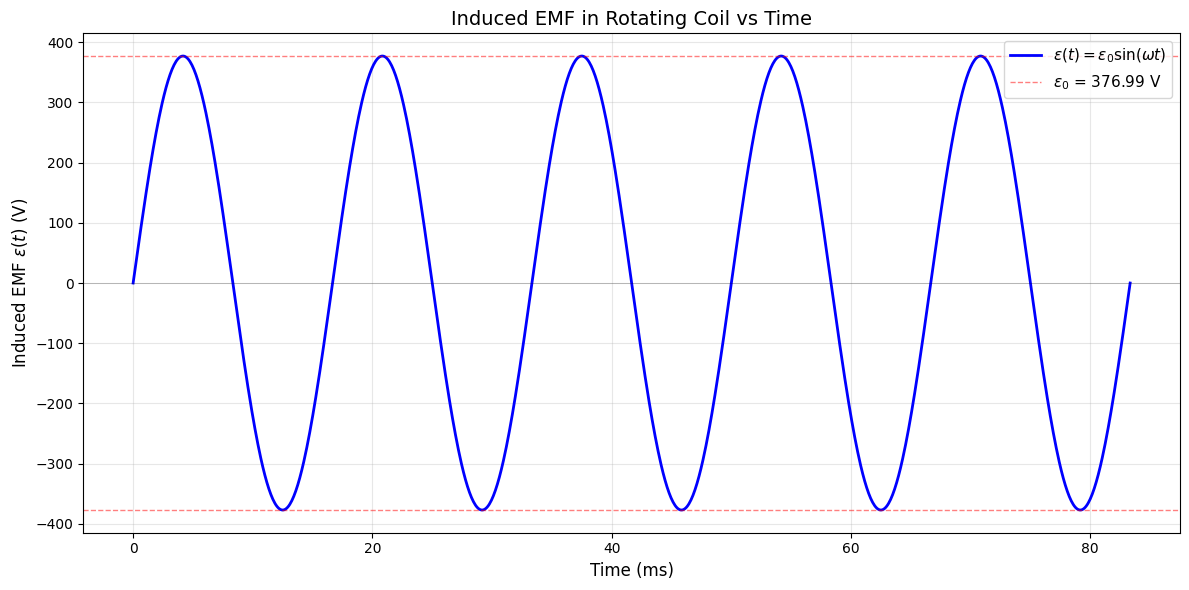

Peak EMF (ε₀): 376.99 V
Angular frequency (ω): 376.99 rad/s
Frequency (f): 60 Hz
Period (T): 16.67 ms


In [3]:
# plots for epsilon(t)
# This code was written by Copilot in VSCode
# it is based on results from the conceptual questions

import numpy as np
import matplotlib.pyplot as plt

# Given parameters from Problem 5
B = 0.5          # Magnetic field in Tesla
A = 0.01         # Area in m^2
N = 200          # Number of turns
f = 60           # Frequency in Hz
R_tot = 10       # Total resistance in Ohms

# Calculate angular frequency
omega = 2 * np.pi * f  # rad/s

# Calculate peak emf: epsilon_0 = NBA*omega
epsilon_0 = N * B * A * omega

# Time array: several periods (let's do 5 periods)
n_periods = 5
T = 1 / f  # Period
t = np.linspace(0, n_periods * T, 1000)

# Calculate emf(t) = epsilon_0 * sin(omega*t)
epsilon_t = epsilon_0 * np.sin(omega * t)

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(t * 1000, epsilon_t, 'b-', linewidth=2, label=r'$\epsilon(t) = \epsilon_0 \sin(\omega t)$')
plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.axhline(y=epsilon_0, color='r', linestyle='--', linewidth=1, alpha=0.5, label=f'$\epsilon_0$ = {epsilon_0:.2f} V')
plt.axhline(y=-epsilon_0, color='r', linestyle='--', linewidth=1, alpha=0.5)

plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('Induced EMF $\epsilon(t)$ (V)', fontsize=12)
plt.title('Induced EMF in Rotating Coil vs Time', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print key values
print(f"Peak EMF (ε₀): {epsilon_0:.2f} V")
print(f"Angular frequency (ω): {omega:.2f} rad/s")
print(f"Frequency (f): {f} Hz")
print(f"Period (T): {T*1000:.2f} ms")



$\omega L/R_{tot} = 0.1$ (Resistance Dom.)
  L_eff = 2.65 mH
  Impedance Z = 10.050 Ω
  Phase angle φ = 5.71° = 0.0996 rad
  Peak current I_0 = 37.512 A

$\omega L/R_{tot} = 1$ (Transitional)
  L_eff = 26.50 mH
  Impedance Z = 14.135 Ω
  Phase angle φ = 44.97° = 0.7849 rad
  Peak current I_0 = 26.670 A

$\omega L/R_{tot} = 10$ (Inductance Dom.)
  L_eff = 265.00 mH
  Impedance Z = 100.402 Ω
  Phase angle φ = 84.28° = 1.4710 rad
  Peak current I_0 = 3.755 A


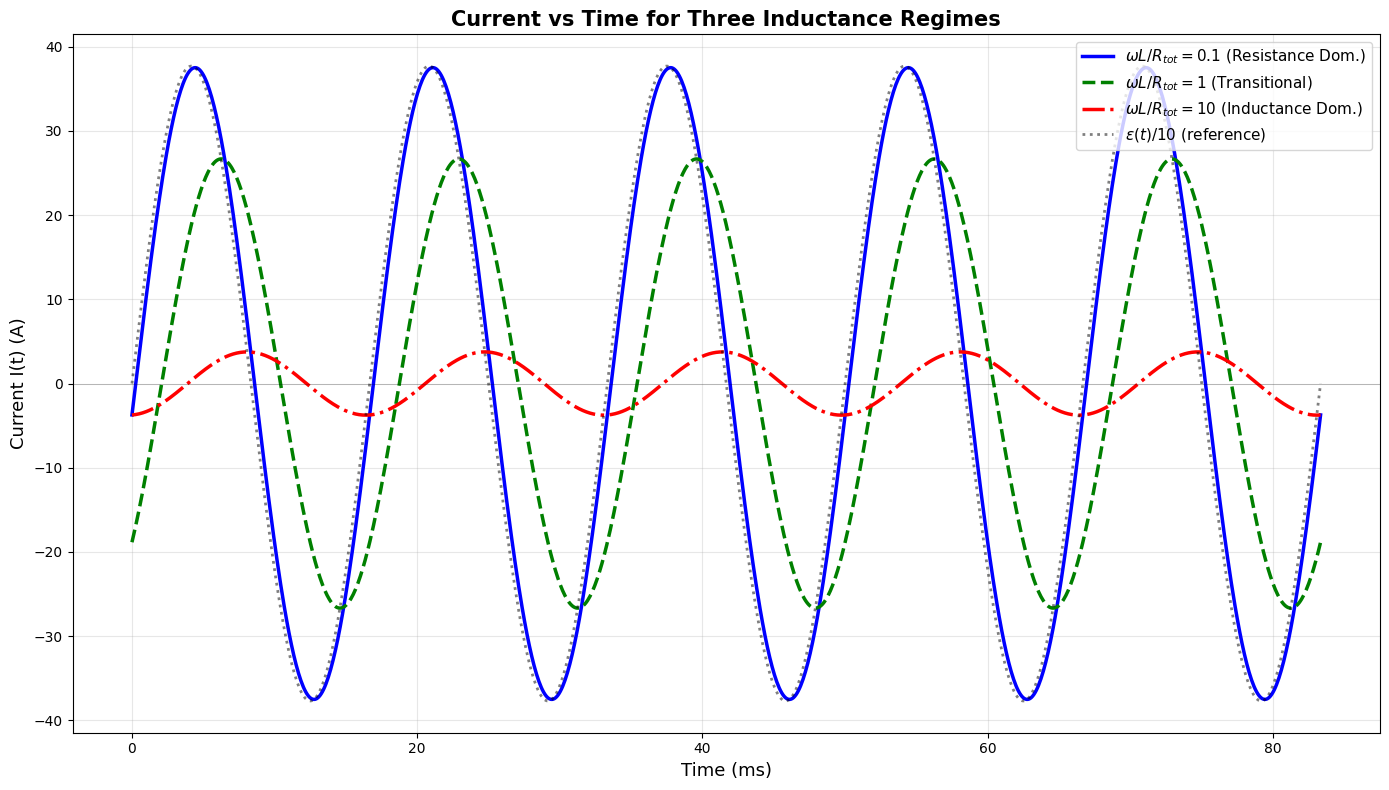


PHASE ANGLE OBSERVATIONS:
• Resistance Dominated (ωL/R = 0.1): φ ≈ 5.7°
  → Current nearly in phase with EMF (minimal lag)

• Transitional (ωL/R = 1): φ = 45°
  → Current lags EMF by 1/8 of a period

• Inductance Dominated (ωL/R = 10): φ ≈ 84.3°
  → Current lags EMF by nearly 1/4 period (almost 90°)
  → Inductor strongly opposes current changes


In [4]:
# Plots for I(t)
# This code was written by Copilot in VSCode
# it is based on results from the conceptual questions

import numpy as np
import matplotlib.pyplot as plt

# Given parameters from Problem 5
B = 0.5          # Magnetic field in Tesla
A = 0.01         # Area in m^2
N = 200          # Number of turns
f = 60           # Frequency in Hz
R_tot = 10       # Total resistance in Ohms
omega = 2 * np.pi * f  # rad/s

# Calculate peak emf: epsilon_0 = NBA*omega
epsilon_0 = N * B * A * omega

# Three inductance cases from Part 10
L_eff = [2.65e-3, 26.5e-3, 265e-3]  # [2.65 mH, 26.5 mH, 265 mH]
ratios = [0.1, 1, 10]
labels = [r'$\omega L/R_{tot} = 0.1$ (Resistance Dom.)', 
          r'$\omega L/R_{tot} = 1$ (Transitional)', 
          r'$\omega L/R_{tot} = 10$ (Inductance Dom.)']
colors = ['blue', 'green', 'red']
linestyles = ['-', '--', '-.']

# Time array: several periods (5 periods)
n_periods = 5
T = 1 / f
t = np.linspace(0, n_periods * T, 1000)

# Create the plot
plt.figure(figsize=(14, 8))

for i, (L, ratio, label, color, ls) in enumerate(zip(L_eff, ratios, labels, colors, linestyles)):
    # Calculate impedance Z and phase angle phi
    Z = np.sqrt(R_tot**2 + (omega * L)**2)
    phi = np.arctan(omega * L / R_tot)
    
    # Calculate peak current I_0
    I_0 = epsilon_0 / Z
    
    # Calculate I(t) = I_0 * sin(omega*t - phi)
    I_t = I_0 * np.sin(omega * t - phi)
    
    plt.plot(t * 1000, I_t, color=color, linestyle=ls, linewidth=2.5, label=label)
    
    # Print key values
    print(f"\n{label}")
    print(f"  L_eff = {L*1e3:.2f} mH")
    print(f"  Impedance Z = {Z:.3f} Ω")
    print(f"  Phase angle φ = {np.degrees(phi):.2f}° = {phi:.4f} rad")
    print(f"  Peak current I_0 = {I_0:.3f} A")

# Also plot emf for reference (scaled down to fit)
epsilon_t = epsilon_0 * np.sin(omega * t)
plt.plot(t * 1000, epsilon_t / 10, 'k:', linewidth=2, alpha=0.5, 
         label=r'$\epsilon(t)/10$ (reference)')

plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.xlabel('Time (ms)', fontsize=13)
plt.ylabel('Current I(t) (A)', fontsize=13)
plt.title('Current vs Time for Three Inductance Regimes', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# Summary of phase behavior
print("\n" + "="*60)
print("PHASE ANGLE OBSERVATIONS:")
print("="*60)
print("• Resistance Dominated (ωL/R = 0.1): φ ≈ 5.7°")
print("  → Current nearly in phase with EMF (minimal lag)")
print("\n• Transitional (ωL/R = 1): φ = 45°")
print("  → Current lags EMF by 1/8 of a period")
print("\n• Inductance Dominated (ωL/R = 10): φ ≈ 84.3°")
print("  → Current lags EMF by nearly 1/4 period (almost 90°)")
print("  → Inductor strongly opposes current changes")




$\omega L/R_{tot} = 0.1$ (Resistance Dom.)
  L_eff = 2.65 mH
  Phase angle φ = 5.71° = 0.0996 rad
  Peak current I_0 = 37.512 A
  Time-averaged torque ⟨τ⟩ = 18.6633 N·m
  Torque oscillates between -0.0929 and 37.4195 N·m

$\omega L/R_{tot} = 1$ (Transitional)
  L_eff = 26.50 mH
  Phase angle φ = 44.97° = 0.7849 rad
  Peak current I_0 = 26.670 A
  Time-averaged torque ⟨τ⟩ = 9.4340 N·m
  Torque oscillates between -3.9012 and 22.7691 N·m

$\omega L/R_{tot} = 10$ (Inductance Dom.)
  L_eff = 265.00 mH
  Phase angle φ = 84.28° = 1.4710 rad
  Peak current I_0 = 3.755 A
  Time-averaged torque ⟨τ⟩ = 0.1870 N·m
  Torque oscillates between -1.6904 and 2.0644 N·m


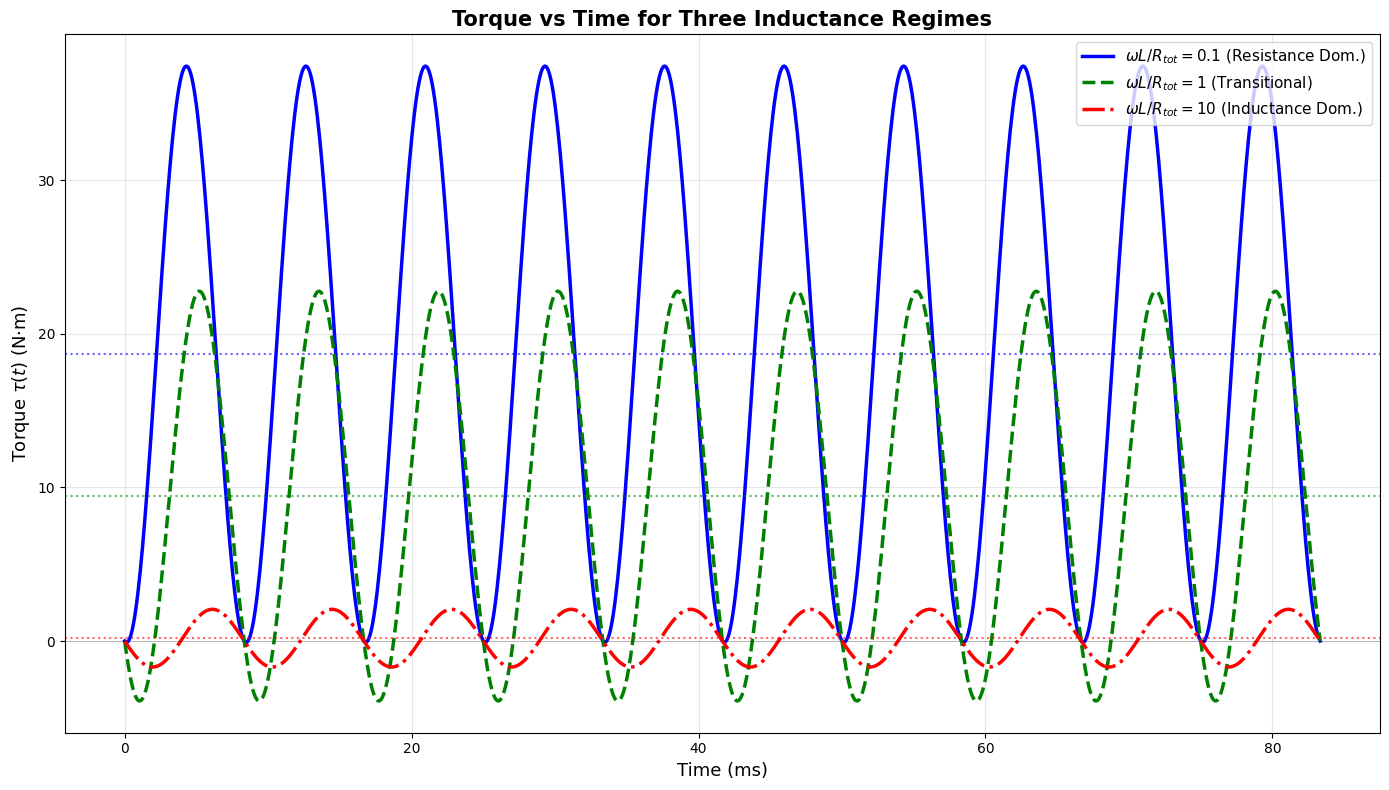


TORQUE OBSERVATIONS:
• Torque oscillates at 2ω (120 Hz) - twice the rotation frequency!

• Resistance Dominated (ωL/R = 0.1):
  → Highest average torque ⟨τ⟩ (cos(5.7°) ≈ 0.995)
  → Large oscillation amplitude around average
  → Requires most mechanical power input

• Transitional (ωL/R = 1):
  → Medium average torque (cos(45°) ≈ 0.707)
  → Phase angle clearly affects average torque

• Inductance Dominated (ωL/R = 10):
  → Lowest average torque (cos(84.3°) ≈ 0.099)
  → Small oscillation amplitude
  → Inductor causes poor power transfer efficiency

• The average torque (dotted lines) decreases as φ increases
  because ⟨τ⟩ ∝ cos(φ)


In [5]:
# Plots for tau(t)
# This code was written by Copilot in VSCode
# it is based on results from the conceptual questions

import numpy as np
import matplotlib.pyplot as plt

# Given parameters from Problem 5
B = 0.5          # Magnetic field in Tesla
A = 0.01         # Area in m^2
N = 200          # Number of turns
f = 60           # Frequency in Hz
R_tot = 10       # Total resistance in Ohms
omega = 2 * np.pi * f  # rad/s

# Calculate peak emf: epsilon_0 = NBA*omega
epsilon_0 = N * B * A * omega

# Three inductance cases from Part 10
L_eff = [2.65e-3, 26.5e-3, 265e-3]  # [2.65 mH, 26.5 mH, 265 mH]
ratios = [0.1, 1, 10]
labels = [r'$\omega L/R_{tot} = 0.1$ (Resistance Dom.)', 
          r'$\omega L/R_{tot} = 1$ (Transitional)', 
          r'$\omega L/R_{tot} = 10$ (Inductance Dom.)']
colors = ['blue', 'green', 'red']
linestyles = ['-', '--', '-.']

# Time array: several periods (5 periods)
n_periods = 5
T = 1 / f
t = np.linspace(0, n_periods * T, 1000)

# Create the plot
plt.figure(figsize=(14, 8))

for i, (L, ratio, label, color, ls) in enumerate(zip(L_eff, ratios, labels, colors, linestyles)):
    # Calculate impedance Z and phase angle phi
    Z = np.sqrt(R_tot**2 + (omega * L)**2)
    phi = np.arctan(omega * L / R_tot)
    
    # Calculate peak current I_0
    I_0 = epsilon_0 / Z
    
    # Calculate tau(t) = (NAB*I_0/2) * [cos(phi) - cos(2*omega*t - phi)]
    tau_t = (N * A * B * I_0 / 2) * (np.cos(phi) - np.cos(2 * omega * t - phi))
    
    # Calculate time-averaged torque
    tau_avg = (N * A * B * I_0 / 2) * np.cos(phi)
    
    plt.plot(t * 1000, tau_t, color=color, linestyle=ls, linewidth=2.5, label=label)
    
    # Plot the average torque as a horizontal line
    plt.axhline(y=tau_avg, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    
    # Print key values
    print(f"\n{label}")
    print(f"  L_eff = {L*1e3:.2f} mH")
    print(f"  Phase angle φ = {np.degrees(phi):.2f}° = {phi:.4f} rad")
    print(f"  Peak current I_0 = {I_0:.3f} A")
    print(f"  Time-averaged torque ⟨τ⟩ = {tau_avg:.4f} N·m")
    print(f"  Torque oscillates between {tau_avg - N*A*B*I_0/2:.4f} and {tau_avg + N*A*B*I_0/2:.4f} N·m")

plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.xlabel('Time (ms)', fontsize=13)
plt.ylabel('Torque $\\tau(t)$ (N·m)', fontsize=13)
plt.title('Torque vs Time for Three Inductance Regimes', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# Summary of torque behavior
print("\n" + "="*70)
print("TORQUE OBSERVATIONS:")
print("="*70)
print("• Torque oscillates at 2ω (120 Hz) - twice the rotation frequency!")
print("\n• Resistance Dominated (ωL/R = 0.1):")
print("  → Highest average torque ⟨τ⟩ (cos(5.7°) ≈ 0.995)")
print("  → Large oscillation amplitude around average")
print("  → Requires most mechanical power input")
print("\n• Transitional (ωL/R = 1):")
print("  → Medium average torque (cos(45°) ≈ 0.707)")
print("  → Phase angle clearly affects average torque")
print("\n• Inductance Dominated (ωL/R = 10):")
print("  → Lowest average torque (cos(84.3°) ≈ 0.099)")
print("  → Small oscillation amplitude")
print("  → Inductor causes poor power transfer efficiency")
print("\n• The average torque (dotted lines) decreases as φ increases")
print("  because ⟨τ⟩ ∝ cos(φ)")



$\omega L/R_{tot} = 0.1$ (Resistance Dom.)
  L_eff = 2.65 mH
  Phase angle φ = 5.71° = 0.0996 rad
  Peak current I_0 = 37.512 A
  Time-averaged mechanical power ⟨P_mech⟩ = 7035.893 W
  P_mech oscillates between -35.024 and 14106.810 W

$\omega L/R_{tot} = 1$ (Transitional)
  L_eff = 26.50 mH
  Phase angle φ = 44.97° = 0.7849 rad
  Peak current I_0 = 26.670 A
  Time-averaged mechanical power ⟨P_mech⟩ = 3556.518 W
  P_mech oscillates between -1470.710 and 8583.747 W

$\omega L/R_{tot} = 10$ (Inductance Dom.)
  L_eff = 265.00 mH
  Phase angle φ = 84.28° = 1.4710 rad
  Peak current I_0 = 3.755 A
  Time-averaged mechanical power ⟨P_mech⟩ = 70.493 W
  P_mech oscillates between -637.274 and 778.261 W


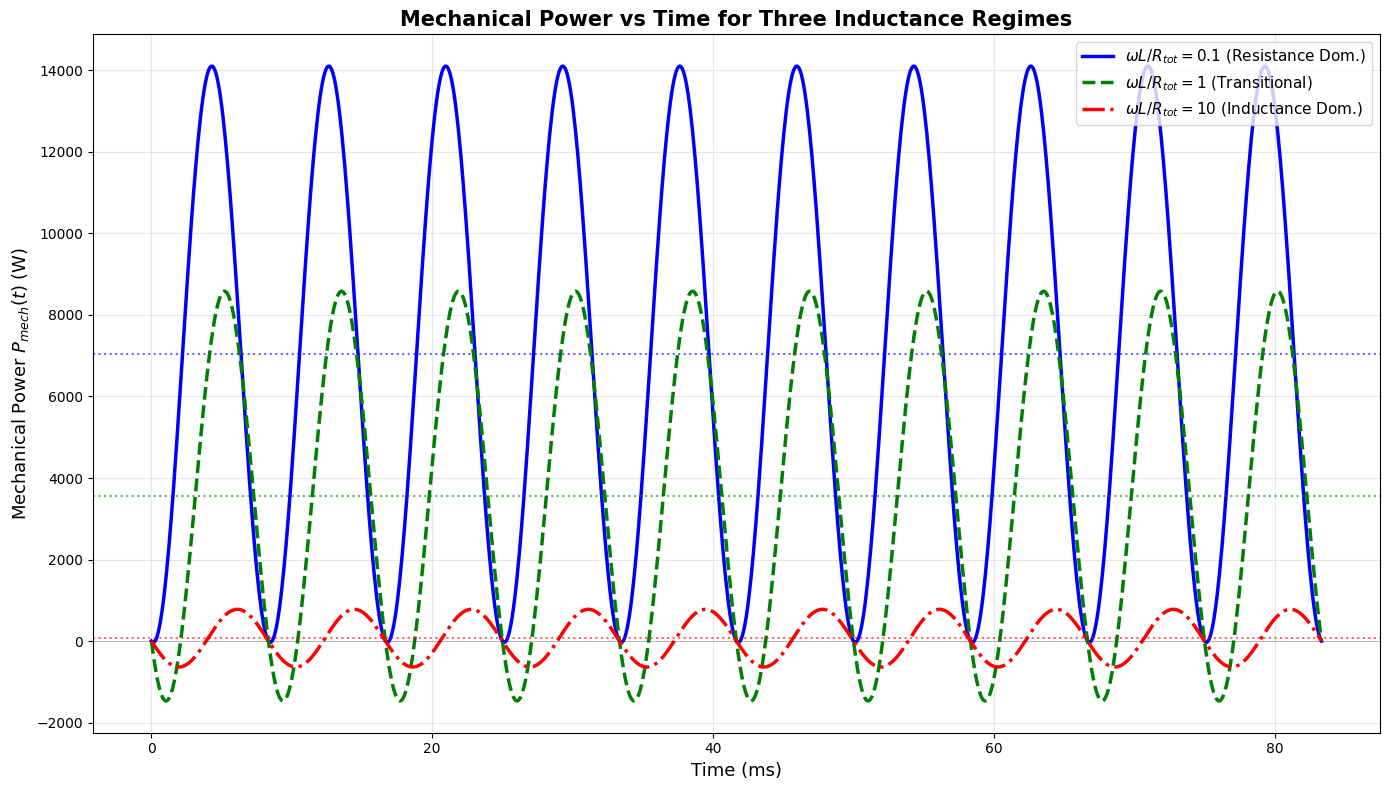


MECHANICAL POWER OBSERVATIONS:
• P_mech oscillates at 2ω (120 Hz) - same as torque!

• Resistance Dominated (ωL/R = 0.1):
  → Highest average power ⟨P_mech⟩ (most efficient power transfer)
  → Large oscillation amplitude
  → Generator delivers maximum mechanical power

• Transitional (ωL/R = 1):
  → Medium average power (cos(45°) = 0.707 reduces efficiency)
  → Phase lag causes power factor reduction

• Inductance Dominated (ωL/R = 10):
  → Lowest average power (cos(84.3°) ≈ 0.1 severely limits transfer)
  → Very small oscillation amplitude
  → Nearly 90° phase lag causes poor power factor
  → Most mechanical energy goes into 'pushing' against inductance

• The average power (dotted lines) shows ⟨P_mech⟩ ∝ cos(φ)
  → cos(φ) is the 'power factor' in AC circuits!
  → As φ → 90°, less real power is transferred


In [6]:
# Plots for P_mech(t)
# This code was written by Copilot in VSCode
# it is based on results from the conceptual questions

import numpy as np
import matplotlib.pyplot as plt

# Given parameters from Problem 5
B = 0.5          # Magnetic field in Tesla
A = 0.01         # Area in m^2
N = 200          # Number of turns
f = 60           # Frequency in Hz
R_tot = 10       # Total resistance in Ohms
omega = 2 * np.pi * f  # rad/s

# Calculate peak emf: epsilon_0 = NBA*omega
epsilon_0 = N * B * A * omega

# Three inductance cases from Part 10
L_eff = [2.65e-3, 26.5e-3, 265e-3]  # [2.65 mH, 26.5 mH, 265 mH]
ratios = [0.1, 1, 10]
labels = [r'$\omega L/R_{tot} = 0.1$ (Resistance Dom.)', 
          r'$\omega L/R_{tot} = 1$ (Transitional)', 
          r'$\omega L/R_{tot} = 10$ (Inductance Dom.)']
colors = ['blue', 'green', 'red']
linestyles = ['-', '--', '-.']

# Time array: several periods (5 periods)
n_periods = 5
T = 1 / f
t = np.linspace(0, n_periods * T, 1000)

# Create the plot
plt.figure(figsize=(14, 8))

for i, (L, ratio, label, color, ls) in enumerate(zip(L_eff, ratios, labels, colors, linestyles)):
    # Calculate impedance Z and phase angle phi
    Z = np.sqrt(R_tot**2 + (omega * L)**2)
    phi = np.arctan(omega * L / R_tot)
    
    # Calculate peak current I_0
    I_0 = epsilon_0 / Z
    
    # Calculate P_mech(t) = tau(t) * omega
    # tau(t) = (NAB*I_0/2) * [cos(phi) - cos(2*omega*t - phi)]
    # P_mech(t) = (NAB*I_0*omega/2) * [cos(phi) - cos(2*omega*t - phi)]
    P_mech_t = (N * A * B * I_0 * omega / 2) * (np.cos(phi) - np.cos(2 * omega * t - phi))
    
    # Calculate time-averaged mechanical power
    P_mech_avg = (N * A * B * I_0 * omega / 2) * np.cos(phi)
    
    plt.plot(t * 1000, P_mech_t, color=color, linestyle=ls, linewidth=2.5, label=label)
    
    # Plot the average power as a horizontal line
    plt.axhline(y=P_mech_avg, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    
    # Print key values
    print(f"\n{label}")
    print(f"  L_eff = {L*1e3:.2f} mH")
    print(f"  Phase angle φ = {np.degrees(phi):.2f}° = {phi:.4f} rad")
    print(f"  Peak current I_0 = {I_0:.3f} A")
    print(f"  Time-averaged mechanical power ⟨P_mech⟩ = {P_mech_avg:.3f} W")
    print(f"  P_mech oscillates between {P_mech_avg - N*A*B*I_0*omega/2:.3f} and {P_mech_avg + N*A*B*I_0*omega/2:.3f} W")

plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.xlabel('Time (ms)', fontsize=13)
plt.ylabel('Mechanical Power $P_{mech}(t)$ (W)', fontsize=13)
plt.title('Mechanical Power vs Time for Three Inductance Regimes', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# Summary of mechanical power behavior
print("\n" + "="*70)
print("MECHANICAL POWER OBSERVATIONS:")
print("="*70)
print("• P_mech oscillates at 2ω (120 Hz) - same as torque!")
print("\n• Resistance Dominated (ωL/R = 0.1):")
print("  → Highest average power ⟨P_mech⟩ (most efficient power transfer)")
print("  → Large oscillation amplitude")
print("  → Generator delivers maximum mechanical power")
print("\n• Transitional (ωL/R = 1):")
print("  → Medium average power (cos(45°) = 0.707 reduces efficiency)")
print("  → Phase lag causes power factor reduction")
print("\n• Inductance Dominated (ωL/R = 10):")
print("  → Lowest average power (cos(84.3°) ≈ 0.1 severely limits transfer)")
print("  → Very small oscillation amplitude")
print("  → Nearly 90° phase lag causes poor power factor")
print("  → Most mechanical energy goes into 'pushing' against inductance")
print("\n• The average power (dotted lines) shows ⟨P_mech⟩ ∝ cos(φ)")
print("  → cos(φ) is the 'power factor' in AC circuits!")
print("  → As φ → 90°, less real power is transferred")


$\omega L/R_{tot} = 0.1$ (Resistance Dom.)
  L_eff = 2.65 mH
  Phase angle φ = 5.71° = 0.0996 rad
  Peak current I_0 = 37.512 A
  Time-averaged electrical power ⟨P_elec⟩ = 7035.893 W
  P_elec oscillates between 0 and 14071.786 W
  Verification: ⟨P_mech⟩ = 7035.893 W (should equal ⟨P_elec⟩)
  Difference: 0.000000 W

$\omega L/R_{tot} = 1$ (Transitional)
  L_eff = 26.50 mH
  Phase angle φ = 44.97° = 0.7849 rad
  Peak current I_0 = 26.670 A
  Time-averaged electrical power ⟨P_elec⟩ = 3556.518 W
  P_elec oscillates between 0 and 7113.037 W
  Verification: ⟨P_mech⟩ = 3556.518 W (should equal ⟨P_elec⟩)
  Difference: 0.000000 W

$\omega L/R_{tot} = 10$ (Inductance Dom.)
  L_eff = 265.00 mH
  Phase angle φ = 84.28° = 1.4710 rad
  Peak current I_0 = 3.755 A
  Time-averaged electrical power ⟨P_elec⟩ = 70.493 W
  P_elec oscillates between 0 and 140.987 W
  Verification: ⟨P_mech⟩ = 70.493 W (should equal ⟨P_elec⟩)
  Difference: 0.000000 W


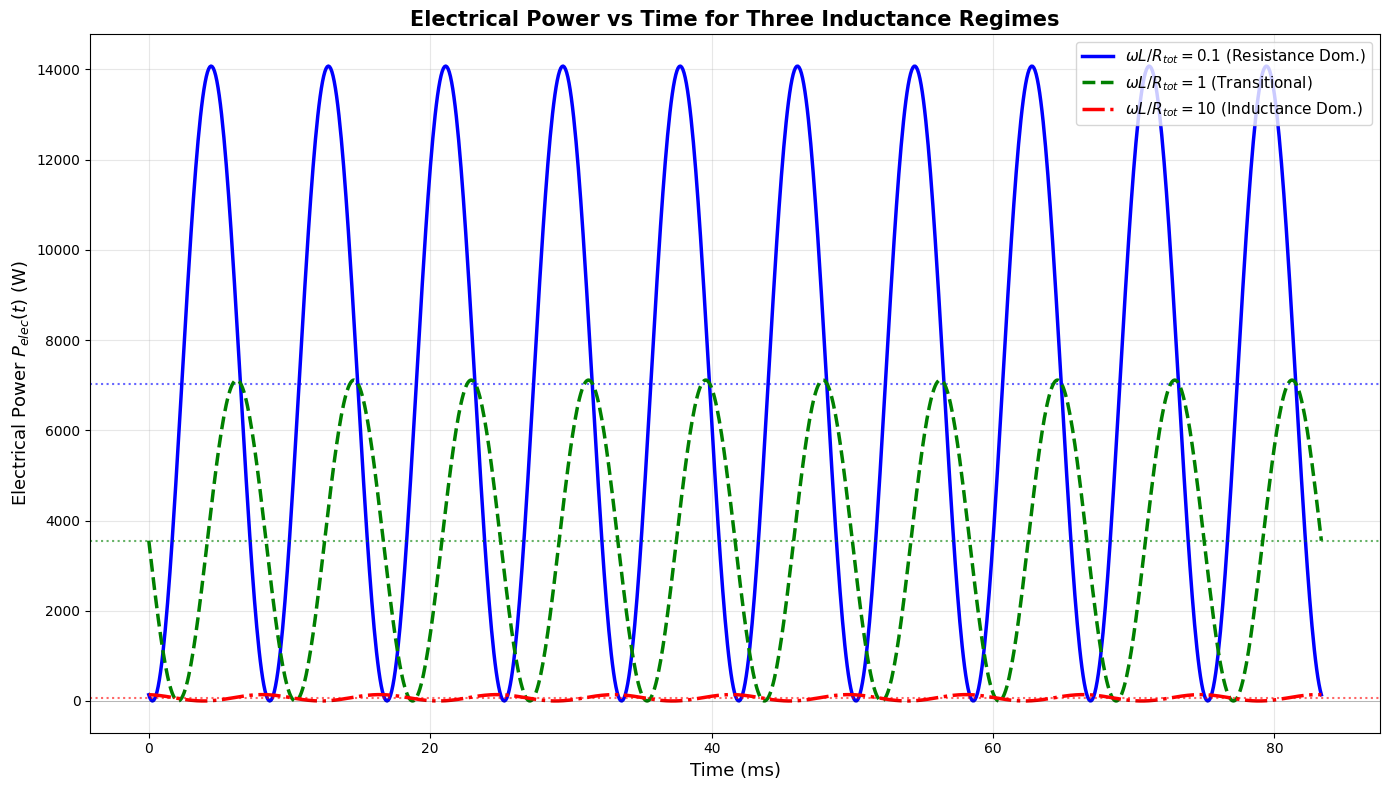


ELECTRICAL POWER OBSERVATIONS:
• P_elec oscillates at 2ω (120 Hz) - always positive!
  → Unlike P_mech which can be negative, P_elec = I²R ≥ 0 always

• Resistance Dominated (ωL/R = 0.1):
  → Highest average power ⟨P_elec⟩
  → Best power transfer efficiency
  → Small phase lag means current and voltage nearly aligned

• Transitional (ωL/R = 1):
  → Medium average power (reduced by ~50% from optimal)
  → 45° phase lag reduces power factor to cos(45°) = 0.707

• Inductance Dominated (ωL/R = 10):
  → Lowest average power (reduced by ~90% from optimal)
  → 84.3° phase lag causes power factor ≈ 0.1
  → Most energy stored/released by inductor, not dissipated

• Phase angle effects:
  → Larger φ → current lags voltage more → lower average power
  → Power oscillation frequency (2ω) independent of phase angle
  → ⟨P_elec⟩ = ⟨P_mech⟩ confirms energy conservation! ✓

• Key insight: P_elec is always non-negative (resistors dissipate)
  while P_mech can be negative (generator absorbs mechanical wo

In [7]:
# Plots for P_elec(t)
# This code was written by Copilot in VSCode
# it is based on results from the conceptual questions

import numpy as np
import matplotlib.pyplot as plt

# Given parameters from Problem 5
B = 0.5          # Magnetic field in Tesla
A = 0.01         # Area in m^2
N = 200          # Number of turns
f = 60           # Frequency in Hz
R_tot = 10       # Total resistance in Ohms
omega = 2 * np.pi * f  # rad/s

# Calculate peak emf: epsilon_0 = NBA*omega
epsilon_0 = N * B * A * omega

# Three inductance cases from Part 10
L_eff = [2.65e-3, 26.5e-3, 265e-3]  # [2.65 mH, 26.5 mH, 265 mH]
ratios = [0.1, 1, 10]
labels = [r'$\omega L/R_{tot} = 0.1$ (Resistance Dom.)', 
          r'$\omega L/R_{tot} = 1$ (Transitional)', 
          r'$\omega L/R_{tot} = 10$ (Inductance Dom.)']
colors = ['blue', 'green', 'red']
linestyles = ['-', '--', '-.']

# Time array: several periods (5 periods)
n_periods = 5
T = 1 / f
t = np.linspace(0, n_periods * T, 1000)

# Create the plot
plt.figure(figsize=(14, 8))

for i, (L, ratio, label, color, ls) in enumerate(zip(L_eff, ratios, labels, colors, linestyles)):
    # Calculate impedance Z and phase angle phi
    Z = np.sqrt(R_tot**2 + (omega * L)**2)
    phi = np.arctan(omega * L / R_tot)
    
    # Calculate peak current I_0
    I_0 = epsilon_0 / Z
    
    # Calculate P_elec(t) = I(t)^2 * R_tot
    # I(t) = I_0 * sin(omega*t - phi)
    # P_elec(t) = I_0^2 * R_tot * sin^2(omega*t - phi)
    I_t = I_0 * np.sin(omega * t - phi)
    P_elec_t = I_t**2 * R_tot
    
    # Calculate time-averaged electrical power
    # <sin^2> = 1/2, so <P_elec> = (1/2) * I_0^2 * R_tot
    P_elec_avg = 0.5 * I_0**2 * R_tot
    
    plt.plot(t * 1000, P_elec_t, color=color, linestyle=ls, linewidth=2.5, label=label)
    
    # Plot the average power as a horizontal line
    plt.axhline(y=P_elec_avg, color=color, linestyle=':', linewidth=1.5, alpha=0.6)
    
    # Print key values
    print(f"\n{label}")
    print(f"  L_eff = {L*1e3:.2f} mH")
    print(f"  Phase angle φ = {np.degrees(phi):.2f}° = {phi:.4f} rad")
    print(f"  Peak current I_0 = {I_0:.3f} A")
    print(f"  Time-averaged electrical power ⟨P_elec⟩ = {P_elec_avg:.3f} W")
    print(f"  P_elec oscillates between 0 and {I_0**2 * R_tot:.3f} W")
    
    # Verify P_elec = P_mech (should be equal)
    P_mech_avg = (N * A * B * I_0 * omega / 2) * np.cos(phi)
    print(f"  Verification: ⟨P_mech⟩ = {P_mech_avg:.3f} W (should equal ⟨P_elec⟩)")
    print(f"  Difference: {abs(P_elec_avg - P_mech_avg):.6f} W")

plt.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.3)
plt.xlabel('Time (ms)', fontsize=13)
plt.ylabel('Electrical Power $P_{elec}(t)$ (W)', fontsize=13)
plt.title('Electrical Power vs Time for Three Inductance Regimes', fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc='upper right')
plt.tight_layout()
plt.show()

# Summary of electrical power behavior
print("\n" + "="*70)
print("ELECTRICAL POWER OBSERVATIONS:")
print("="*70)
print("• P_elec oscillates at 2ω (120 Hz) - always positive!")
print("  → Unlike P_mech which can be negative, P_elec = I²R ≥ 0 always")
print("\n• Resistance Dominated (ωL/R = 0.1):")
print("  → Highest average power ⟨P_elec⟩")
print("  → Best power transfer efficiency")
print("  → Small phase lag means current and voltage nearly aligned")
print("\n• Transitional (ωL/R = 1):")
print("  → Medium average power (reduced by ~50% from optimal)")
print("  → 45° phase lag reduces power factor to cos(45°) = 0.707")
print("\n• Inductance Dominated (ωL/R = 10):")
print("  → Lowest average power (reduced by ~90% from optimal)")
print("  → 84.3° phase lag causes power factor ≈ 0.1")
print("  → Most energy stored/released by inductor, not dissipated")
print("\n• Phase angle effects:")
print("  → Larger φ → current lags voltage more → lower average power")
print("  → Power oscillation frequency (2ω) independent of phase angle")
print("  → ⟨P_elec⟩ = ⟨P_mech⟩ confirms energy conservation! ✓")
print("\n• Key insight: P_elec is always non-negative (resistors dissipate)")
print("  while P_mech can be negative (generator absorbs mechanical work)")